# Python и машинное обучение: нейронные сети и компьютерное зрение

## Модуль 3. Перенос обучения

In [ ]:
!pip install torchinfo torchmetrics

In [ ]:
import os, shutil

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets,transforms
from torch.nn.functional import normalize

from torchinfo import summary
from torchmetrics import Accuracy, AUROC

from torch.utils.data.sampler import SubsetRandomSampler
import torch.nn.functional as F

from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
device = "cuda" if torch.cuda.is_available() else \
    "mps" if torch.backends.mps.is_built() else "cpu"
device

## Датасет

Будет использоваться тот же набор данных cats vs. dogs: `https://www.kaggle.com/c/dogs-vs-cats/data`.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!cp -r /content/drive/MyDrive/cats_and_dogs_small /content/data

In [ ]:
!ls -al /content/data

In [ ]:
IMAGE_WIDTH, IMAGE_HEIGHT = IMAGE_SIZE = (150,150)
NUM_WORKERS = os.cpu_count()
print(f'Cores: {NUM_WORKERS}')
BATCH_SIZE = 20


base_dir = '/home/ise/Documents/datasets/cats_and_dogs_small'
# base_dir = '/content/data'

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

data_transforms = transforms.Compose([ transforms.Resize(size=IMAGE_SIZE), transforms.ToTensor(), ])

train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transforms, 
                                  target_transform=None)
val_data = datasets.ImageFolder(root=validation_dir, transform=data_transforms)

train_gen = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=NUM_WORKERS,
                              shuffle=True)

val_gen = DataLoader(dataset=val_data, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=True)

images, labels = next(iter(train_gen))

fig = plt.figure(figsize=(20, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 20//2, idx+1, xticks=[], yticks=[])
    ax.imshow(np.transpose(images[idx], (1,2,0)))
    ax.set_title(train_data.classes[labels[idx].item()])

### Загрузка моделей

Загружать уже обученные модели можно либо ```torchvision.models```, ```torch.hub```, а также просто загружать из файлов, скачанных из интернета.

In [ ]:
import torchvision.models as models

models.list_models(module=models)

Загрузим несколько моделей:

In [ ]:
model = models.alexnet(weights='DEFAULT')
# model = models.vgg16(weights='DEFAULT')
# model = models.googlenet(weights='DEFAULT')
# model = models.resnet50(weights='DEFAULT')
# model = models.resnet18(weights='DEFAULT')
# model = models.mobilenet_v3_small(weights='DEFAULT')
# print(model)
summary(model,
        input_size=(1, 3, 150, 150),
        col_names=["input_size", "output_size", "num_params"],
        device=device
       )

Подготовим изображение из валидационной выборки и запустим инференс.

In [ ]:
images, _ = next(iter(val_gen))

image = images[12:13]

display(transforms.ToPILImage()(image[0]))

In [ ]:
model.eval()
results = model(image.to(device))
results

In [ ]:
percentage = torch.nn.functional.softmax(results, dim=1)[0] * 100
top = torch.sort(percentage, descending=True)
list(zip(*top))[:5]

In [ ]:
import requests

imagenet_classes = requests.get('https://files.fast.ai/models/imagenet_class_index.json').json()
imagenet_classes

In [ ]:
predictions = [f"{imagenet_classes[str(ix.cpu().item())][1]} - {pct:.2f}%" \
               for pct, ix in zip(*top) ][:5]
display(transforms.ToPILImage()(image[0]))
predictions

### Перенос обучения (transfer learning)

Продемонстрируем перенос обучения на примере сети resnet50. 

In [ ]:
transfer_model = models.resnet50(weights='DEFAULT')
print(transfer_model)

In [ ]:
# морозим веса во всей модели, кроме слоев BatchNorm
for name, param in transfer_model.named_parameters():
    if("bn" not in name):
        param.requires_grad = False

In [ ]:
# подменяем классификатор
transfer_model.fc = nn.Sequential(nn.Linear(transfer_model.fc.in_features,500),
nn.ReLU(),                                 
nn.Dropout(), nn.Linear(500,2)) 

In [ ]:
# возьмем нашу функцию для обучения бинарного классификатора
def train_batches(model, optimizer, criterion,
                  train_generator,
                  valid_generator,
                  batch_size=20, epochs=40, report_positions=20, **kwargs):

    results = {'epoch_count': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    # прогоняем данные по нейросети
    for epoch in range(epochs):
        model.train()

        train_loss = valid_loss = 0.0;
        train_correct = valid_correct = 0.0

        for X_batch, y_batch in train_generator:

            X_batch = X_batch.to(device); y_batch = y_batch.to(device)

            y_preds = model(X_batch)
            loss = criterion(y_preds, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.data.item()
            train_correct += (y_preds.argmax(dim=1) == y_batch).float().sum()

        train_loss /= len(train_generator.dataset)
        train_acc = 100 * train_correct / len(train_generator.dataset)

        # Валидацию тоже делаем по батчам
        model.eval()

        for valid_batches, (X_val_batch, y_val_batch) in enumerate(valid_generator):
            X_val_batch = X_val_batch.to(device); y_val_batch = y_val_batch.to(device)
            y_batch_preds = model(X_val_batch)
            loss = criterion(y_batch_preds, y_val_batch)

            valid_loss += loss.data.item()
            valid_correct += (y_batch_preds.argmax(dim=1) == y_val_batch).float().sum()

        valid_loss /= len(valid_generator.dataset)
        valid_acc = 100 * valid_correct / len(valid_generator.dataset)

        results['epoch_count'] += [epoch]
        results['train_loss'] += [ train_loss ]
        results['train_acc'] += [ float(train_acc) ]
        results['val_loss'] += [ valid_loss ]
        results['val_acc'] += [ float(valid_acc) ]

        if (True if epochs<50 else epoch % (epochs // report_positions) == 0 ):
            print(f"Epoch: {epoch+1:4.0f} | Train Loss: {train_loss:.5f}, "+\
                  f"Accuracy: {train_acc:.2f}% | \
            Validation Loss: {valid_loss:.5f}, Accuracy: {valid_acc:.2f}%")

    return results

# рисовалка графиков
def plot_results(results):

    fig, axs = plt.subplots(1,2)

    fig.set_size_inches(10,3)

    for i, loss_acc in enumerate(['loss', 'acc']):
        for train_val in ['train', 'val']:
            axs[i].plot(results['epoch_count'], results[f'{train_val}_{loss_acc}'], label=f'{loss_acc} {train_val}')

        axs[i].legend()

    plt.show()

In [ ]:
import copy

a_model = copy.deepcopy(transfer_model).to(device)

optimizer = torch.optim.Adam(a_model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

results = train_batches(a_model, optimizer, criterion,
                        train_gen,
                        val_gen, epochs=7)

plot_results(results)

In [ ]:
images, labels = next(iter(val_gen))

a_model.eval()

preds = a_model(images.to(device))
pred_labels = preds.argmax(dim=1)

fig = plt.figure(figsize=(20, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 20//2, idx+1, xticks=[], yticks=[])
    ax.imshow(np.transpose(images[idx].cpu().numpy(), (1,2,0)))
    ax.set_title(train_data.classes[labels[idx].item()]+' '+train_data.classes[pred_labels[idx].item()])

In [ ]:
summary(transfer_model,
        input_size=(1, 3, 150, 150),
        col_names=["input_size", "output_size", "num_params"],
        device=device
       )

**ПРАКТИКА**

Попробуйте поэкспериментировать с параметрами дообучения, например, с количеством эпох, learning rate и т.д. Сравните результаты с обучением "с ноля" (без переноса обучения).

In [ ]:
# ваш код здесь

## Data Augmentation

Что поможет нам расширить обучающий набор? Если мы применим к каждой картинке некое преобразование (например, будем ее "зеркалить" по горизонтали) - это уже увеличит объем выборки вдвое. Можно также применять другие преобразования, которые оставят картинку узнаваемой человеком (глядя на нее любой сможет сказать: "смотрите, это кот!"), но при этом сделают ее "новой" для нейросети. Например, можно картинку немного увеличивать, слегка поворачивать, чуть-чуть сдвигать.

Такие преобразования называют "аугментацией данных" - расширением обучающего набора на базе имеющегося, таким образом, что сохраняется принадлежность образцов к исходным классам.

К счастью, нам не придется писать такие преобразователи "с ноля", в Keras уже есть соответствующий функционал, причем он встроен в уже немного знакомый нам ```ImageDataGenerator```.

Вот примерный набор таких преобразований:

In [ ]:
# аугментатор
p = 0.5
data_augmentator = transforms.Compose([
    transforms.Resize(size=IMAGE_SIZE), # делаем все картинки квадратными
    transforms.RandomRotation(40),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)),
    transforms.RandomPerspective(distortion_scale=0.2, p=p),
    transforms.RandomResizedCrop(size=IMAGE_SIZE, scale=(0.8, 0.8)),
    transforms.RandomHorizontalFlip(p=p),
    transforms.ToTensor(), # преобразуем в тензор
])

In [ ]:
train_data_aug = datasets.ImageFolder(root=train_dir,
                                  transform=data_augmentator, # <--- !!!
                                  target_transform=None)

train_gen_aug = DataLoader(dataset=train_data_aug,
                              batch_size=BATCH_SIZE,
                              num_workers=NUM_WORKERS,
                              shuffle=True)

In [ ]:
images, labels = next(iter(train_gen_aug))

fig = plt.figure(figsize=(20, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 20//2, idx+1, xticks=[], yticks=[])
    ax.imshow(np.transpose(images[idx], (1,2,0)))
    ax.set_title(train_data.classes[labels[idx].item()])

In [ ]:
images, labels = next(iter(train_gen))

fig = plt.figure(figsize=(20, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 20//2, idx+1, xticks=[], yticks=[])
    ax.imshow(np.transpose(images[idx], (1,2,0)))
    ax.set_title(train_data.classes[labels[idx].item()])

In [ ]:
a_model = copy.deepcopy(transfer_model).to(device)

optimizer = torch.optim.Adam(a_model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

results = train_batches(a_model, optimizer, criterion,
                        train_gen_aug,
                        val_gen, epochs=7)

plot_results(results)





**ПРАКТИКА**

Дообучите другие модели: AlexNet, MobileNetV3, VGG, попробуйте поэкспериментировать с параметрами аугментации данных, сравните результаты с обучением без аугментации.

In [ ]:
# ваш код здесь



### Другие приемы переноса обучения

Как "разморозить" нужные слои?

In [ ]:
# снова возьмем resnet50
transfer_model = models.resnet50(weights='DEFAULT')

# морозим слои
for name, param in transfer_model.named_parameters():
    if("bn" not in name):
        param.requires_grad = False

# подменяем классификатор
transfer_model.fc = nn.Sequential(nn.Linear(transfer_model.fc.in_features,500),
nn.ReLU(),                                 
nn.Dropout(), nn.Linear(500,2))
        
print(transfer_model)

In [ ]:
unfreeze_layers = [transfer_model.layer3, transfer_model.layer4] 

for layer in unfreeze_layers:
    for param in layer.parameters():
        param.requires_grad = True

In [ ]:
summary(transfer_model,
        input_size=(1, 3, 150, 150),
        col_names=["input_size", "output_size", "num_params"],
        device=device
       )

Еще можно задать различным слоям разную скорость обучения:

In [ ]:
lr = 0.001
optimizer = torch.optim.Adam([
    { 'params': transfer_model.layer4.parameters(), 'lr': lr /3},
    { 'params': transfer_model.layer3.parameters(), 'lr': lr /9}, 
    ], lr=lr)

In [ ]:
transfer_model = transfer_model.to(device)
criterion = torch.nn.CrossEntropyLoss()

results = train_batches(transfer_model,
                        optimizer, criterion,
                        train_gen_aug,
                        val_gen, epochs=10, )

plot_results(results)

**ПРАКТИКА**

Попробуйте обучить resnet50 на нашем датасете, заморозив все слои, кроме последнего. Сравните качество с обучением без заморозки слоев.

In [ ]:
#ваш код здесь



## Дообучение Vision Transformers

Vision Transformers - это архитектура, которая была адаптирована из трансформеров, которые изначально были разработаны для обработки последовательностей (например, текста). Они показали отличные результаты в задачах компьютерного зрения, особенно при обучении на больших объемах данных.

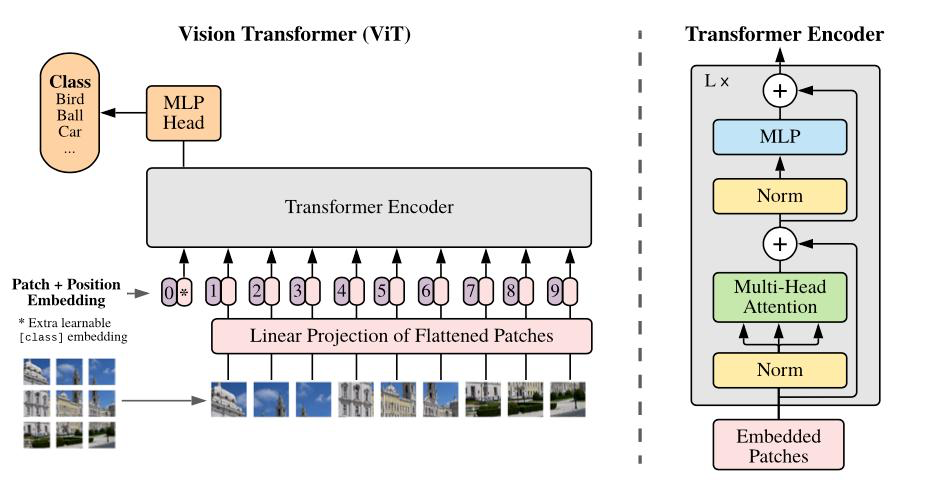


In [ ]:
vit_weights = models.ViT_B_16_Weights.DEFAULT

vit_model = models.vit_b_16(weights=vit_weights)
summary(vit_model,
        input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params"],
        device=device
       )


In [ ]:
print(vit_model)

In [ ]:
# 1) Морозим backbone
for param in vit_model.parameters():
    param.requires_grad = False

# 2) Размораживаем последние 2 encoder-блока (опционально, для более гибкого fine-tuning)
for param in vit_model.encoder.layers[-2:].parameters():
    param.requires_grad = True

# 3) Подменяем голову на 2 класса
in_features = vit_model.heads.head.in_features
vit_model.heads.head = nn.Linear(in_features, 2)

summary(vit_model,
        input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params"],
        device=device
       )

In [ ]:
# Vision Transformer (ViT) для cats vs dogs
# Используем тот же train_dir/validation_dir из тетради

# ViT обучался на 224x224 и ImageNet-нормализации
vit_train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop((224, 224), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

vit_val_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

vit_train_data = datasets.ImageFolder(root=train_dir, transform=vit_train_tfms)
vit_val_data = datasets.ImageFolder(root=validation_dir, transform=vit_val_tfms)

# ViT обычно требует меньший batch из-за памяти
vit_batch_size = min(BATCH_SIZE, 16)

vit_train_gen = DataLoader(
    dataset=vit_train_data,
    batch_size=vit_batch_size,
    num_workers=NUM_WORKERS,
    shuffle=True
)

vit_val_gen = DataLoader(
    dataset=vit_val_data,
    batch_size=vit_batch_size,
    num_workers=NUM_WORKERS,
    shuffle=False
)

In [ ]:
vit_model = vit_model.to(device)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, vit_model.parameters()),
    lr=3e-4
)
criterion = torch.nn.CrossEntropyLoss()

results = train_batches(
    vit_model,
    optimizer,
    criterion,
    vit_train_gen,
    vit_val_gen,
    epochs=7
)

plot_results(results)

**ПРАКТИКА** 

Для данной модели найдите фото кота и собаки в интернете и запросите классификацию - для этого напишите код, который делает весь необходимый препроцессинг, запускает модель и возвращает метку класса в дружественной форме.

In [ ]:
# ваш код здесь


